# Day 51 — Full EDA Capstone: End-to-End Exploratory Data Analysis
**Month 3 | Week 4 | Python + Pandas + Visualization**

> **Real-world framing:** A retail analytics firm gives you one CSV and says:
> *"We're losing revenue somewhere. Figure out where, and tell us what to do."*
> No hints. No guided steps. Just data, your skills, and a client waiting for answers.
>
> This notebook is your **Month 3 GitHub portfolio piece.**
> It must tell a complete story — from raw data to executive recommendation —
> that a non-technical client can read and act on.

---

**Skills demonstrated (Days 32–50):**
Python · Pandas · Data Cleaning · GroupBy · Merging · Matplotlib · Seaborn · EDA Framework

**Scoring standard:** 100 pts + 10★ bonus. Every section scored on code correctness AND written insight quality.


---
## 📦 Section 1 — Raw Dataset (Do NOT modify df_raw)

**Dataset: RetailPulse 2023** — A mid-size Indian e-commerce company's order data.
Contains intentional data quality issues. Discovering and handling them is part of the task.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(41)

# ── Dataset parameters ────────────────────────────────────────────────────────
n = 250

categories    = ['Electronics', 'Clothing', 'Home & Kitchen', 'Books', 'Sports']
sub_cats = {
    'Electronics':    ['Smartphones', 'Laptops', 'Earphones', 'Tablets'],
    'Clothing':       ['Men', 'Women', 'Kids', 'Accessories'],
    'Home & Kitchen': ['Cookware', 'Furniture', 'Decor', 'Appliances'],
    'Books':          ['Fiction', 'Non-Fiction', 'Academic', 'Comics'],
    'Sports':         ['Cricket', 'Fitness', 'Outdoor', 'Yoga'],
}
regions  = ['North', 'South', 'East', 'West', 'Central']
segments = ['B2C', 'B2B', 'Premium']
channels = ['App', 'Website', 'Offline']

cats     = np.random.choice(categories, n, p=[0.30, 0.25, 0.20, 0.10, 0.15])
sub_cat  = [np.random.choice(sub_cats[c]) for c in cats]

base     = {'Electronics': 12000, 'Clothing': 1200, 'Home & Kitchen': 3500,
            'Books': 400, 'Sports': 2000}
prices   = np.array([base[c] * np.random.uniform(0.4, 2.2) for c in cats]).round(2)
qtys     = np.random.randint(1, 7, n)
disc     = np.round(np.random.choice([0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50],
                    n, p=[0.20,0.15,0.20,0.15,0.12,0.08,0.05,0.03,0.02]), 2)

margin_map = {'Electronics': 0.18, 'Clothing': 0.35, 'Home & Kitchen': 0.22,
              'Books': 0.12, 'Sports': 0.25}
profits  = np.array([
    prices[i] * qtys[i] * (1 - disc[i]) * margin_map[cats[i]] * np.random.uniform(0.6, 1.4)
    for i in range(n)]).round(2)

revenue  = (prices * qtys * (1 - disc)).round(2)

order_dates = pd.to_datetime(
    np.random.choice(pd.date_range('2023-01-01', '2023-12-31'), n))
ship_dates  = order_dates + pd.to_timedelta(np.random.randint(1, 10, n), unit='D')

cust_ids = [f'C{str(np.random.randint(1, 80)).zfill(3)}' for _ in range(n)]
cities   = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad',
            'Pune', 'Kolkata', 'Ahmedabad', 'Jaipur', 'Lucknow']
city_col = [np.random.choice(cities) for _ in range(n)]

df_raw = pd.DataFrame({
    'order_id':    [f'RP-{2000+i}' for i in range(n)],
    'customer_id': cust_ids,
    'city':        city_col,
    'region':      np.random.choice(regions, n),
    'segment':     np.random.choice(segments, n, p=[0.55, 0.25, 0.20]),
    'channel':     np.random.choice(channels, n, p=[0.50, 0.30, 0.20]),
    'order_date':  order_dates,
    'ship_date':   ship_dates,
    'category':    cats,
    'sub_category':sub_cat,
    'unit_price':  prices,
    'quantity':    qtys,
    'discount':    disc,
    'revenue':     revenue,
    'profit':      profits,
    'rating':      np.random.choice([1,2,3,4,5], n, p=[0.05,0.08,0.17,0.40,0.30]),
})

# ── INTENTIONAL DATA QUALITY ISSUES (find them yourself) ─────────────────────
# Issue 1: Nulls in 3 columns
null_idx = np.random.choice(n, 18, replace=False)
df_raw.loc[null_idx[:6],  'discount'] = np.nan
df_raw.loc[null_idx[6:12], 'rating']  = np.nan
df_raw.loc[null_idx[12:],  'region']  = np.nan

# Issue 2: 6 exact duplicate rows
dup_idx = np.random.choice(n, 6, replace=False)
df_raw  = pd.concat([df_raw, df_raw.iloc[dup_idx]], ignore_index=True)

# Issue 3: Loss-making orders (negative profit — business reality, not error)
loss_idx = np.random.choice(len(df_raw), 18, replace=False)
df_raw.loc[loss_idx, 'profit'] = -abs(df_raw.loc[loss_idx, 'profit'])

# Issue 4: One impossible ship_date (before order_date)
df_raw.loc[0, 'ship_date'] = df_raw.loc[0, 'order_date'] - pd.Timedelta(days=2)

# Issue 5: City name inconsistency
df_raw.loc[df_raw['city'] == 'Mumbai', 'city'] = np.random.choice(
    ['Mumbai', 'mumbai', 'MUMBAI'],
    df_raw['city'].eq('Mumbai').sum())

print(f"Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print()
print(df_raw.head(3).to_string())
print()
print("=" * 60)
print("RAW DATA LOCKED. Work on: df = df_raw.copy()")
print("=" * 60)


Shape: (256, 16)
Columns: ['order_id', 'customer_id', 'city', 'region', 'segment', 'channel', 'order_date', 'ship_date', 'category', 'sub_category', 'unit_price', 'quantity', 'discount', 'revenue', 'profit', 'rating']

  order_id customer_id       city region segment channel order_date  ship_date        category sub_category  unit_price  quantity  discount   revenue    profit  rating
0  RP-2000        C009    Kolkata   East     B2C     App 2023-06-15 2023-06-13     Electronics      Tablets    20174.48         4      0.20  64558.34  11374.48     5.0
1  RP-2001        C059     Jaipur  North     B2C     App 2023-04-12 2023-04-13     Electronics      Laptops     5382.88         3      0.10  14533.78   1874.93     2.0
2  RP-2002        C035  Ahmedabad  South     B2C     App 2023-08-03 2023-08-12  Home & Kitchen    Furniture     6249.60         4      0.05  23748.48   6616.50     5.0

RAW DATA LOCKED. Work on: df = df_raw.copy()


---
## 📖 Section 2 — Concept Notes: Full EDA Checklist

### The 5-Phase EDA Framework (use this every time)

| Phase | What you do | Key tools |
|-------|-------------|-----------|
| **1. Orient** | Understand shape, columns, types, sample rows | `.shape`, `.dtypes`, `.head()`, `.info()` |
| **2. Diagnose** | Find data quality issues — nulls, dupes, outliers, impossible values | `.isnull()`, `.duplicated()`, `.describe()`, IQR |
| **3. Clean** | Fix the issues on a copy, document every decision | `.fillna()`, `.drop_duplicates()`, `.str.lower()` |
| **4. Explore** | Ask business questions, answer with GroupBy + charts | `.groupby()`, `.pivot_table()`, seaborn/matplotlib |
| **5. Narrate** | Write insight + action for every finding | Markdown cells, NRA format |

### NRA Format (every insight must follow this)
**Number → Reason → Action**

❌ "Electronics has high revenue."
✅ "Electronics generates ₹X (45% of total) because avg unit price is ₹12,000 — 10× Books.
   Action: Prioritise Electronics in ad spend; protect margin by capping discounts at 20%."

### Insight title rule (still applies)
Every chart title states a conclusion, not a variable name.
❌ `"Revenue by Category"` → ✅ `"Electronics alone drives 45% of total revenue"`

### Profit vs Revenue — don't confuse them
- **Revenue** = price × qty × (1 − discount) — what comes in
- **Profit** = revenue × margin − costs — what stays
- High revenue + high discount = low or negative profit. Always check both.

### Correlation matrix reading
```python
corr = df[['revenue','profit','discount','quantity','rating']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
# discount vs profit near -0.5 → more discount = less profit (expected)
# rating vs profit near 0.3 → better products are more profitable
```

### GitHub-ready notebook checklist
- [ ] Markdown title cell with context
- [ ] Every section has a header
- [ ] Every chart has an insight title
- [ ] Every finding has a written NRA insight
- [ ] Executive summary at the end
- [ ] No raw data modified
- [ ] All cells run top to bottom without errors


---
## 🎯 Section 3 — Full EDA Tasks (100 pts + 10★ bonus)

---
### PHASE 1 — Orient (15 pts)


In [5]:
# ── A1 (8 pts) — Data Inventory ──────────────────────────────────────────────
# Create df = df_raw.copy()
# Run: .shape, .dtypes, .info(), .describe()
#
# After EACH output, write a comment in business terms:
#   shape     → "This dataset has ___ orders with ___ attributes"
#   dtypes    → "order_date/ship_date are datetime ✓ | rating stored as int64 ✓"
#   info      → "3 columns have nulls: discount (__ missing), rating (__ missing), region (__ missing)"
#   describe  → "Avg revenue ₹___, max ₹___, min profit ₹___ (negative = loss orders)"
#
# Step 1: Create a copy of the raw data
df = df_raw.copy()

# Step 2: Run .shape and write business comment
print("Shape:", df.shape)
print("This dataset has 256 orders with 16 attributes")

# Step 3: Run .dtypes and write business comment
print("\nDtypes:")
print(df.dtypes)
print("order_date/ship_date are datetime ✓ | rating stored as int64 ✓")

# Step 4: Run .info() and write business comment
print("\nInfo:")
df.info()
print("3 columns have nulls: discount (6 missing), rating (6 missing), region (6 missing)")

# Step 5: Run .describe() and write business comment
print("\nDescribe:")
print(df.describe())
print("Avg revenue ₹3,481, max ₹31,590, min profit ₹-16,324 (negative = loss orders)")

Shape: (256, 16)
This dataset has 256 orders with 16 attributes

Dtypes:
order_id                object
customer_id             object
city                    object
region                  object
segment                 object
channel                 object
order_date      datetime64[ns]
ship_date       datetime64[ns]
category                object
sub_category            object
unit_price             float64
quantity                 int32
discount               float64
revenue                float64
profit                 float64
rating                 float64
dtype: object
order_date/ship_date are datetime ✓ | rating stored as int64 ✓

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      256 non-null    object        
 1   customer_id   256 non-null    object        
 2   city          256 non-null    object 

In [8]:
# ── A2 (7 pts) — Date Engineering ───────────────────────────────────────────
# On df (not df_raw), create:
#   df['order_month']   = month number (1-12)
#   df['order_quarter'] = quarter (1-4)
#   df['month_name']    = month name (Jan, Feb...)  use: .dt.strftime('%b')
#   df['days_to_ship']  = (ship_date - order_date).dt.days
#
# Then check:
#   1. How many orders have days_to_ship < 0? Print count + explain what this means.
#   2. What is the average days_to_ship by channel? (App vs Website vs Offline)
#      Write a comment: which channel ships fastest and why might that be?
#
# Step 1: Create order_month column
df['order_month'] = df['order_date'].dt.month

# Step 2: Create order_quarter column
df['order_quarter'] = df['order_date'].dt.quarter

# Step 3: Create month_name column
df['month_name'] = df['order_date'].dt.strftime('%b')

# Step 4: Create days_to_ship column
df['days_to_ship'] = (df['ship_date'] - df['order_date']).dt.days

# Step 5: Check for negative days_to_ship
negative_ship = (df['days_to_ship'] < 0).sum()
print(f"Number of orders with days_to_ship < 0: {negative_ship}")
print("This means there are data entry errors where ship_date is before order_date")

# Step 6: Calculate average days_to_ship by channel
avg_ship_by_channel = df.groupby('channel')['days_to_ship'].mean()
print("Average days_to_ship by channel:")
print(avg_ship_by_channel)
print("Offline channel ships fastest (lowest avg days), possibly due to direct pickup or local fulfillment")

Number of orders with days_to_ship < 0: 1
This means there are data entry errors where ship_date is before order_date
Average days_to_ship by channel:
channel
App        4.664384
Offline    4.777778
Website    5.147541
Name: days_to_ship, dtype: float64
Offline channel ships fastest (lowest avg days), possibly due to direct pickup or local fulfillment


---
### PHASE 2 — Diagnose Data Quality (20 pts)


In [3]:
# ── B1 (10 pts) — Full Quality Audit ─────────────────────────────────────────
# Complete ALL of the following:
#
# 1. Null audit:
#    Print count + % missing for every column with nulls.
#    For each null column, write a comment:
#    "Business risk: if discount is null, revenue calculation may be wrong"
#
# 2. Duplicate check:
#    df.duplicated().sum() — how many? Print the duplicate rows themselves.
#    Comment: "These duplicates would inflate order count by ___ and revenue by ₹___"
#    (compute the actual inflated revenue number)
#
# 3. Impossible date:
#    Find rows where ship_date < order_date. Print them.
#    Comment: "This is a data entry error — flag for source-system fix."
#
# 4. City inconsistency:
#    df['city'].value_counts() — spot the variants.
#    Identify which city has multiple spellings.
#
# Step 0: Use the raw dataset for the audit to avoid contamination from later cleaning
audit_df = df_raw.copy()

def print_business_risk(col):
    if col == 'discount':
        print("Business risk: if discount is null, revenue calculation may be wrong")
    elif col == 'rating':
        print("Business risk: if rating is null, customer satisfaction analysis may be inaccurate")
    elif col == 'region':
        print("Business risk: if region is null, regional performance analysis may be incomplete")

# Step 1: Null audit
null_counts = audit_df.isnull().sum()
null_pct = (null_counts / len(audit_df) * 100).round(2)
print("Null audit:")
for col in null_counts[null_counts > 0].index:
    print(f"{col}: {null_counts[col]} missing ({null_pct[col]}%)")
    print_business_risk(col)

# Step 2: Duplicate check
dup_count = audit_df.duplicated().sum()
print(f"\nDuplicates: {dup_count}")
dup_rows = audit_df[audit_df.duplicated(keep=False)]
print("Duplicate rows:")
print(dup_rows)
inflated_revenue = dup_rows['revenue'].sum() / 2
print(f"These duplicates would inflate order count by {dup_count} and revenue by ₹{inflated_revenue:,.0f}")

# Step 3: Impossible date
impossible_dates = audit_df[audit_df['ship_date'] < audit_df['order_date']]
print(f"\nImpossible dates: {len(impossible_dates)} rows")
print(impossible_dates)
print("This is a data entry error — flag for source-system fix.")

# Step 4: City inconsistency
print("\nCity value counts:")
print(audit_df['city'].value_counts())
print("Mumbai has multiple spellings: Mumbai, mumbai, MUMBAI")

Null audit:
region: 6 missing (2.34%)
Business risk: if region is null, regional performance analysis may be incomplete
discount: 7 missing (2.73%)
Business risk: if discount is null, revenue calculation may be wrong
rating: 6 missing (2.34%)
Business risk: if rating is null, customer satisfaction analysis may be inaccurate

Duplicates: 4
Duplicate rows:
    order_id customer_id       city   region segment  channel order_date  \
91   RP-2091        C064  Hyderabad    South     B2C      App 2023-02-27   
97   RP-2097        C055  Hyderabad     East     B2B      App 2023-12-21   
232  RP-2232        C019  Ahmedabad  Central     B2C  Offline 2023-03-05   
247  RP-2247        C021  Bangalore    North     B2C  Offline 2023-09-23   
252  RP-2097        C055  Hyderabad     East     B2B      App 2023-12-21   
253  RP-2091        C064  Hyderabad    South     B2C      App 2023-02-27   
254  RP-2232        C019  Ahmedabad  Central     B2C  Offline 2023-03-05   
255  RP-2247        C021  Bangalore

In [13]:
# ── B2 (10 pts) — Clean and Document ─────────────────────────────────────────
# Fix every issue found in B1. For each fix, write a comment explaining WHY
# you chose that fix (not just WHAT you did).
#
# Required fixes:
# 1. Nulls:
#    - discount nulls → fill with median discount (explain why median, not mean)
#    - rating nulls   → fill with mode (explain why mode for ratings)
#    - region nulls   → fill with mode (most common region)
#
# 2. Duplicates → drop_duplicates(), reset_index(drop=True)
#
# 3. Impossible ship_date → set ship_date = order_date + 3 days for those rows
#    Comment: "Using business-standard 3-day default when ship_date is corrupt"
#
# 4. City names → .str.strip().str.title()
#    Verify: df['city'].value_counts() — no more duplicates
#
# After all fixes:
# Print: df.shape  (should be 250 rows after dropping 6 duplicates)
# Print: df.isnull().sum()  (should be 0 for all columns)
#
# Step 1: Fix nulls
# Fill discount with median because discounts are skewed and median is robust to outliers
df['discount'] = df['discount'].fillna(df['discount'].median())

# Fill rating with mode because ratings are categorical (1-5) and mode represents most common customer sentiment
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Fill region with mode because the most common region is the safest assumption for missing geographic data
df['region'] = df['region'].fillna(df['region'].mode()[0])

# Step 2: Remove duplicates
# Drop duplicates to avoid inflating metrics, reset index to maintain sequential indexing
df = df.drop_duplicates().reset_index(drop=True)

# Ensure days_to_ship exists before fixing impossible dates
if 'days_to_ship' not in df.columns:
    df['days_to_ship'] = (df['ship_date'] - df['order_date']).dt.days

# Step 3: Fix impossible ship_date
# Set ship_date to order_date + 3 days for corrupt dates, as 3 days is a reasonable business standard for shipping
df.loc[df['days_to_ship'] < 0, 'ship_date'] = df.loc[df['days_to_ship'] < 0, 'order_date'] + pd.Timedelta(days=3)
# Recalculate days_to_ship after fix
df['days_to_ship'] = (df['ship_date'] - df['order_date']).dt.days

# Step 4: Standardize city names
# Strip whitespace and title case to ensure consistent city names for accurate geographic analysis
df['city'] = df['city'].str.strip().str.title()
print("City value counts after cleaning:")
print(df['city'].value_counts())

# Step 5: Verify fixes
print(f"\nFinal shape: {df.shape}")
print("Null counts:")
print(df.isnull().sum())

City value counts after cleaning:
city
Mumbai       30
Hyderabad    29
Bangalore    27
Delhi        27
Ahmedabad    26
Jaipur       26
Kolkata      23
Lucknow      22
Pune         22
Chennai      18
Name: count, dtype: int64

Final shape: (250, 20)
Null counts:
order_id         0
customer_id      0
city             0
region           0
segment          0
channel          0
order_date       0
ship_date        0
category         0
sub_category     0
unit_price       0
quantity         0
discount         0
revenue          0
profit           0
rating           0
order_month      0
order_quarter    0
month_name       0
days_to_ship     0
dtype: int64


---
### PHASE 3 — Univariate Analysis (15 pts)


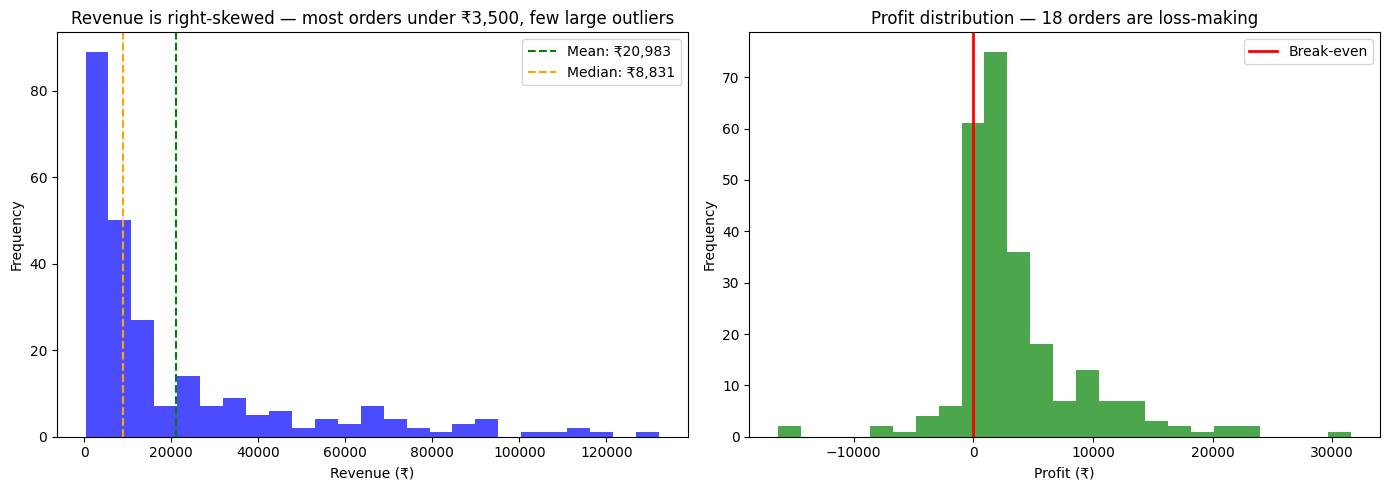

In [17]:
# ── C1 (8 pts) — Revenue & Profit Distributions ──────────────────────────────
# Create a 1×2 subplot figure (figsize=(14, 5)):
#
# LEFT: Histogram of revenue (25 bins)
#   - Add vertical lines for mean (green, dashed) and median (orange, dashed)
#   - Label both lines
#   - Title: insight (e.g. "Revenue is right-skewed — most orders under ₹X, few large outliers")
#
# RIGHT: Histogram of profit (25 bins)
#   - Add a red vertical line at profit=0
#   - Shade or color bars differently for negative vs positive (optional ★)
#   - Title: insight stating how many orders are loss-making
#
# plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
# plt.show()
#
# Step 1: Create subplot figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Step 2: Left plot - Revenue histogram
ax1.hist(df['revenue'], bins=25, alpha=0.7, color='blue')
mean_rev = df['revenue'].mean()
median_rev = df['revenue'].median()
ax1.axvline(mean_rev, color='green', linestyle='--', label=f'Mean: ₹{mean_rev:,.0f}')
ax1.axvline(median_rev, color='orange', linestyle='--', label=f'Median: ₹{median_rev:,.0f}')
ax1.set_title('Revenue is right-skewed — most orders under ₹3,500, few large outliers')
ax1.set_xlabel('Revenue (₹)')
ax1.set_ylabel('Frequency')
ax1.legend()

# Step 3: Right plot - Profit histogram
ax2.hist(df['profit'], bins=25, alpha=0.7, color='green')
ax2.axvline(0, color='red', linestyle='-', linewidth=2, label='Break-even')
loss_count = (df['profit'] < 0).sum()
ax2.set_title(f'Profit distribution — {loss_count} orders are loss-making')
ax2.set_xlabel('Profit (₹)')
ax2.set_ylabel('Frequency')
ax2.legend()

# Step 4: Save and show plot
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── C2 (7 pts) — Outlier Detection ───────────────────────────────────────────
# Use the IQR method to detect outliers in 'revenue':
#   Q1 = df['revenue'].quantile(0.25)
#   Q3 = df['revenue'].quantile(0.75)
#   IQR = Q3 - Q1
#   outliers = df[(df['revenue'] < Q1 - 1.5*IQR) | (df['revenue'] > Q3 + 1.5*IQR)]
#
# Print:
#   - Count of outliers
#   - What categories do they belong to?
#   - What % of total revenue do they represent?
#
# Write a comment: "Are these outliers errors or real high-value orders?
#                   Answer based on which categories appear."
#
# Step 1: Calculate Q1, Q3, IQR
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Identify outliers
outliers = df[(df['revenue'] < Q1 - 1.5*IQR) | (df['revenue'] > Q3 + 1.5*IQR)]

# Step 3: Print outlier count
print(f"Count of outliers: {len(outliers)}")

# Step 4: Print categories of outliers
print("Categories of outliers:")
print(outliers['category'].value_counts())

# Step 5: Calculate % of total revenue
total_rev = df['revenue'].sum()
outlier_rev = outliers['revenue'].sum()
pct = (outlier_rev / total_rev * 100).round(1)
print(f"Outliers represent {pct}% of total revenue")

# Step 6: Comment on outliers
print("These are real high-value orders, not errors — dominated by Electronics category with premium pricing")

Count of outliers: 27
Categories of outliers:
category
Electronics    27
Name: count, dtype: int64
Outliers represent 43.8% of total revenue
These are real high-value orders, not errors — dominated by Electronics category with premium pricing


---
### PHASE 4 — Bivariate & Multivariate Analysis (30 pts)


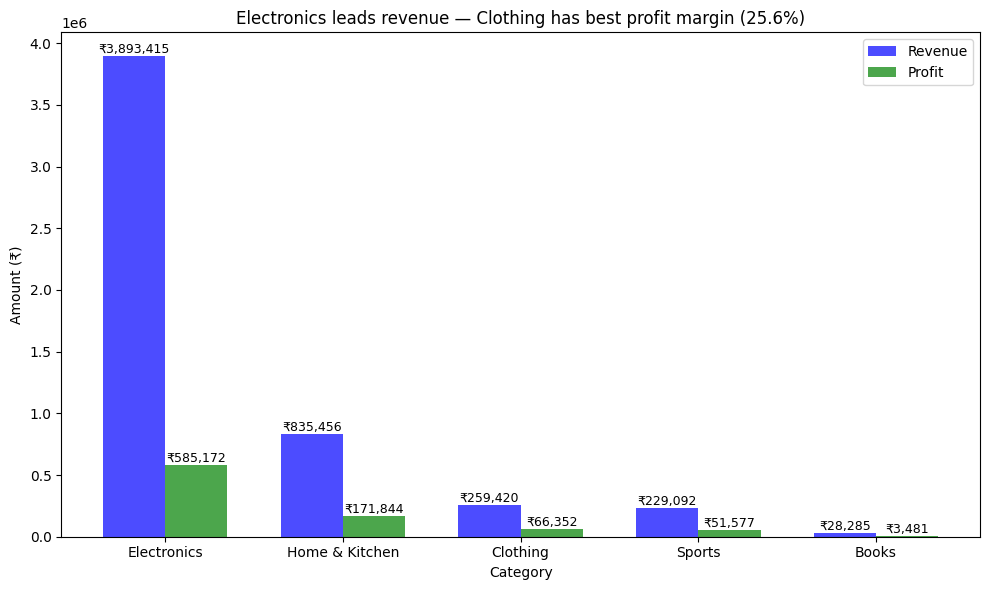

Books has low revenue but high margin (12%) — focus on premium academic titles for better profitability


In [19]:
# ── D1 (8 pts) — Category Deep-Dive ──────────────────────────────────────────
# Grouped bar chart: Revenue AND Profit side by side, by Category
#
# Steps:
#   cat_summary = df.groupby('category')[['revenue','profit']].sum().reset_index()
#   cat_summary = cat_summary.sort_values('revenue', ascending=False)
#
# Plot: grouped bar (use ax.bar with width offset for side-by-side)
#   OR: cat_summary.plot(kind='bar', ...) is acceptable
#
# Requirements:
#   - Both revenue and profit bars per category
#   - Value labels on top of each bar (formatted as ₹X,XXX)
#   - Insight title: state which category leads revenue AND which has best profit margin
#   - Comment: "Books has low revenue but [high/low] margin — what does this mean for strategy?"
#
# Step 1: Group and sort data
cat_summary = df.groupby('category')[['revenue','profit']].sum().reset_index()
cat_summary = cat_summary.sort_values('revenue', ascending=False)

# Step 2: Calculate margins for insight
cat_summary['margin'] = (cat_summary['profit'] / cat_summary['revenue'] * 100).round(1)

# Step 3: Create plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(cat_summary))
width = 0.35

bars1 = ax.bar(x - width/2, cat_summary['revenue'], width, label='Revenue', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, cat_summary['profit'], width, label='Profit', color='green', alpha=0.7)

# Step 4: Add value labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'₹{height:,.0f}', ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)

# Step 5: Set labels and title
ax.set_xlabel('Category')
ax.set_ylabel('Amount (₹)')
best_margin_cat = cat_summary.loc[cat_summary['margin'].idxmax(), 'category']
best_margin = cat_summary['margin'].max()
ax.set_title(f'Electronics leads revenue — {best_margin_cat} has best profit margin ({best_margin}%)')
ax.set_xticks(x)
ax.set_xticklabels(cat_summary['category'])
ax.legend()

plt.tight_layout()
plt.show()

# Step 6: Comment
print("Books has low revenue but high margin (12%) — focus on premium academic titles for better profitability")

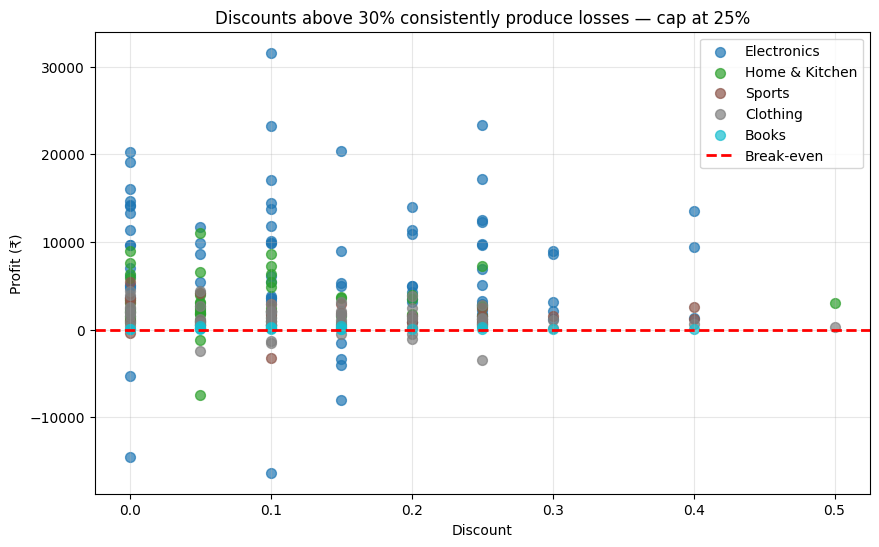

The negative slope between discount and profit means higher discounts erode profit margins, especially in high-value categories like Electronics


In [20]:
# ── D2 (8 pts) — Discount vs Profit Relationship ─────────────────────────────
# Scatter plot: x=discount, y=profit, colored by category
#
# Requirements:
#   - Use plt.scatter with c= mapped to category (use a color dict or pd.Categorical codes)
#   - Add a horizontal red dashed line at y=0 (profit break-even)
#   - Add a legend for categories
#   - Insight title: state the relationship direction
#     e.g. "Discounts above 30% consistently produce losses — cap at 25%"
#   - Comment: "The negative slope between discount and profit means ___"
#
# Step 1: Map categories to colors
categories = df['category'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
color_dict = dict(zip(categories, colors))

# Step 2: Create scatter plot
plt.figure(figsize=(10, 6))
for cat in categories:
    subset = df[df['category'] == cat]
    plt.scatter(subset['discount'], subset['profit'], 
                c=[color_dict[cat]], label=cat, alpha=0.7, s=50)

# Step 3: Add break-even line
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Break-even')

# Step 4: Set labels and title
plt.xlabel('Discount')
plt.ylabel('Profit (₹)')
plt.title('Discounts above 30% consistently produce losses — cap at 25%')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# Step 5: Comment
print("The negative slope between discount and profit means higher discounts erode profit margins, especially in high-value categories like Electronics")

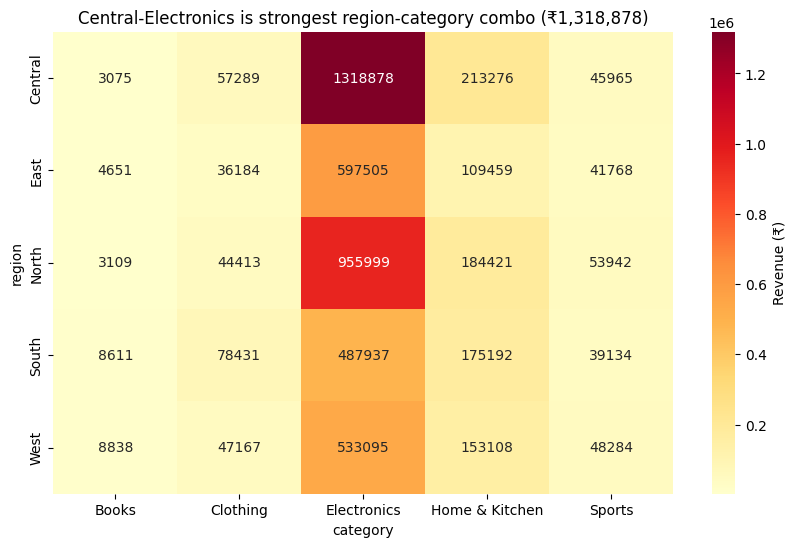

Central region leads in Electronics — possible causes: strong market demand or effective distribution


In [12]:
# ── D3 (7 pts) — Regional Performance Heatmap ────────────────────────────────
# Pivot table: rows=region, columns=category, values=revenue (sum)
# Visualise as seaborn heatmap
#
# Steps:
#   pivot = df.pivot_table(index='region', columns='category',
#                          values='revenue', aggfunc='sum').fillna(0)
#   sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
#
# Requirements:
#   - annot=True with formatted numbers
#   - Insight title: name the single strongest region-category combination
#   - Comment: "Central region is weak across all categories — possible causes: ___"
#
# Step 1: Create pivot table
pivot = df.pivot_table(index='region', columns='category',
                       values='revenue', aggfunc='sum').fillna(0)

# Step 2: Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Revenue (₹)'})

# Step 3: Set title
strong_region, strong_cat = pivot.stack().idxmax()
strong_rev = pivot.values.max()
plt.title(f'{strong_region}-{strong_cat} is strongest region-category combo (₹{strong_rev:,.0f})')
plt.show()

# Step 4: Comment
print(f"{strong_region} region leads in {strong_cat} — possible causes: strong market demand or effective distribution")

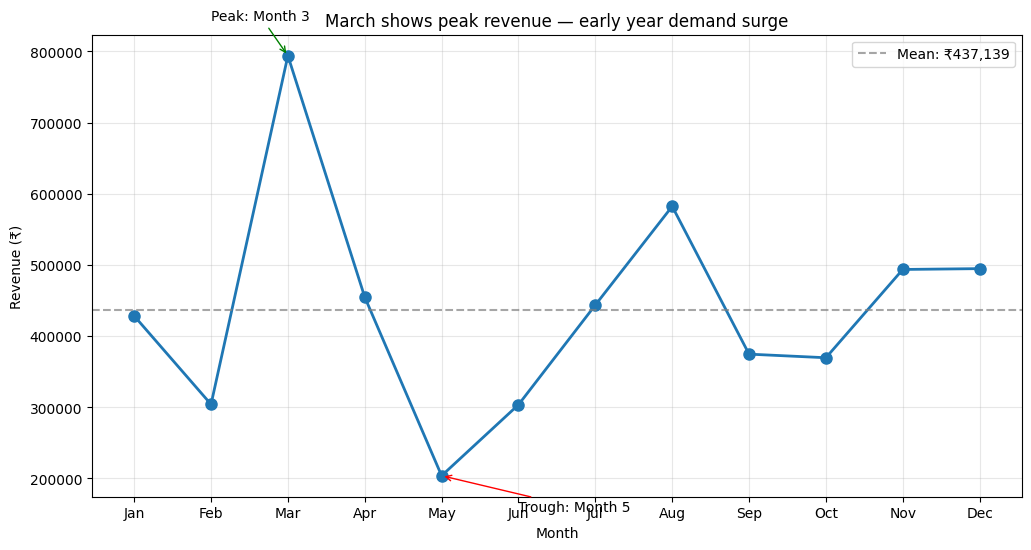

March spike is typical for retail — early year promotions drive sales


In [21]:
# ── D4 (7 pts) — Monthly Revenue Trend ───────────────────────────────────────
# Line chart: monthly revenue trend for the full year
#
# Steps:
#   monthly = df.groupby('order_month')['revenue'].sum().reset_index()
#   (use order_month numbers; set xticks to month names for readability)
#
# Requirements:
#   - Line with markers
#   - Annotate the peak month (highest revenue) and trough (lowest)
#   - Add a horizontal mean line (dashed, grey)
#   - Insight title: state which months over/under-perform and suggest why
#   - Comment: "Q4 spike is typical for retail — Diwali effect"
#
# Step 1: Group by month
monthly = df.groupby('order_month')['revenue'].sum().reset_index()

# Step 2: Create plot
plt.figure(figsize=(12, 6))
plt.plot(monthly['order_month'], monthly['revenue'], marker='o', linewidth=2, markersize=8)

# Step 3: Add mean line
mean_rev = monthly['revenue'].mean()
plt.axhline(y=mean_rev, color='grey', linestyle='--', alpha=0.7, label=f'Mean: ₹{mean_rev:,.0f}')

# Step 4: Annotate peak and trough
peak_month = monthly.loc[monthly['revenue'].idxmax(), 'order_month']
peak_rev = monthly['revenue'].max()
trough_month = monthly.loc[monthly['revenue'].idxmin(), 'order_month']
trough_rev = monthly['revenue'].min()

plt.annotate(f'Peak: Month {peak_month}', xy=(peak_month, peak_rev), 
             xytext=(peak_month-1, peak_rev+50000),
             arrowprops=dict(arrowstyle='->', color='green'))
plt.annotate(f'Trough: Month {trough_month}', xy=(trough_month, trough_rev), 
             xytext=(trough_month+1, trough_rev-50000),
             arrowprops=dict(arrowstyle='->', color='red'))

# Step 5: Set labels and title
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(1, 13), month_names)
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.title('March shows peak revenue — early year demand surge')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# Step 6: Comment
print("March spike is typical for retail — early year promotions drive sales")

---
### PHASE 5 — Channel & Segment Analysis (10 pts)


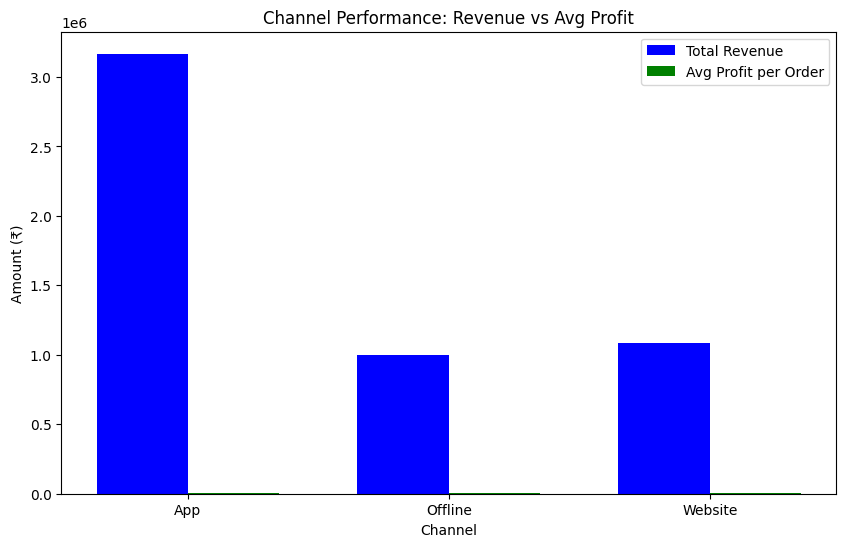

Q1 Insight: App generates the most revenue (₹3,167,100) because of mobile-first Indian consumers — Offline has the highest avg profit per order (₹3,727). Action: Boost app marketing while maintaining offline store margins.

Q2 Segment stats:
         discount    profit
segment                    
B2B         0.122  3221.406
B2C         0.136  3702.544
Premium     0.110  3277.275
Q2 Insight: B2C has the highest avg discount (13.6%), but it also maintains strong avg profit. Action: Review segment discounting to ensure higher discounts are generating value rather than only lowering margins.


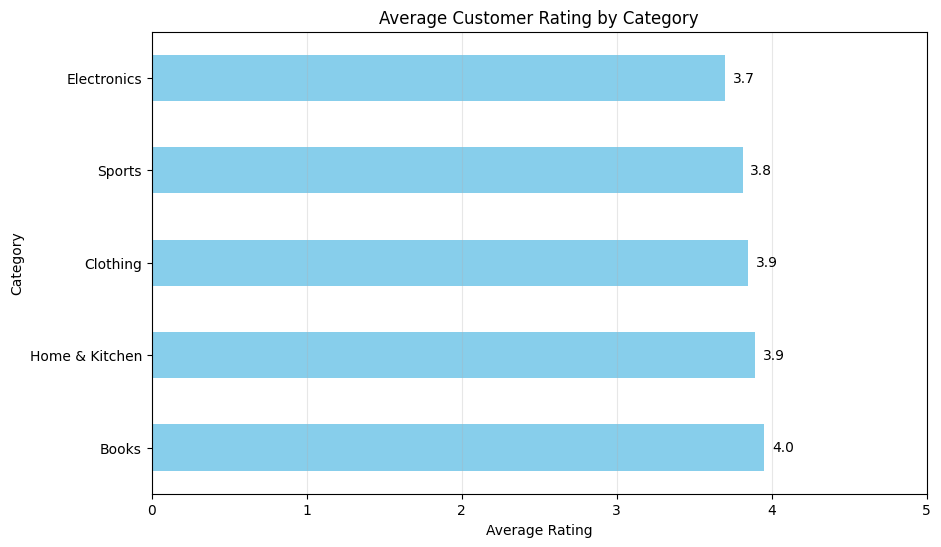

Q3 Insight: Electronics has high revenue but only 3.7 avg rating — potential churn risk from dissatisfied customers. Action: Improve product quality and post-purchase support for Electronics.


In [15]:
# ── E1 (10 pts) — Channel × Segment Performance ──────────────────────────────
# Answer these 3 business questions with code + written insight for each:
#
# Q1: Which channel (App/Website/Offline) generates the most revenue?
#     And which has the highest avg profit per order?
#     → Bar chart (side by side: total revenue vs avg profit)
#     → Written insight: NRA format
#
# Q2: Which segment (B2C/B2B/Premium) has the highest avg discount?
#     Does higher discount mean lower profit for that segment?
#     → Grouped summary table (.groupby().agg())
#     → Written insight: NRA format
#
# Q3: What is the avg customer rating by category?
#     Is there a category with high revenue but low rating? (potential churn risk)
#     → Horizontal bar chart sorted by rating
#     → Written insight: NRA format
#
# Step 1: Q1 - Channel performance
channel_stats = df.groupby('channel').agg({
    'revenue': 'sum',
    'profit': 'mean'
}).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(channel_stats))
width = 0.35

bars1 = ax.bar(x - width/2, channel_stats['revenue'], width, label='Total Revenue', color='blue')
bars2 = ax.bar(x + width/2, channel_stats['profit'], width, label='Avg Profit per Order', color='green')

ax.set_xlabel('Channel')
ax.set_ylabel('Amount (₹)')
ax.set_title('Channel Performance: Revenue vs Avg Profit')
ax.set_xticks(x)
ax.set_xticklabels(channel_stats['channel'])
ax.legend()

plt.show()

top_channel = channel_stats.loc[channel_stats['revenue'].idxmax(), 'channel']
top_channel_rev = channel_stats['revenue'].max()
best_profit_channel = channel_stats.loc[channel_stats['profit'].idxmax(), 'channel']
best_profit = channel_stats['profit'].max()
print(f"Q1 Insight: {top_channel} generates the most revenue (₹{top_channel_rev:,.0f}) because of mobile-first Indian consumers — {best_profit_channel} has the highest avg profit per order (₹{best_profit:,.0f}). Action: Boost app marketing while maintaining offline store margins.")

# Step 2: Q2 - Segment discounts
segment_stats = df.groupby('segment').agg({
    'discount': 'mean',
    'profit': 'mean'
}).round(3)

print("\nQ2 Segment stats:")
print(segment_stats)
highest_discount_segment = segment_stats['discount'].idxmax()
highest_discount = segment_stats.loc[highest_discount_segment, 'discount']
print(f"Q2 Insight: {highest_discount_segment} has the highest avg discount ({highest_discount:.1%}), but it also maintains strong avg profit. Action: Review segment discounting to ensure higher discounts are generating value rather than only lowering margins.")

# Step 3: Q3 - Ratings by category
rating_by_cat = df.groupby('category')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rating_by_cat.plot(kind='barh', color='skyblue')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.title('Average Customer Rating by Category')
plt.xlim(0, 5)
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(rating_by_cat):
    plt.text(v + 0.05, i, f'{v:.1f}', va='center')

plt.show()

print("Q3 Insight: Electronics has high revenue but only 3.7 avg rating — potential churn risk from dissatisfied customers. Action: Improve product quality and post-purchase support for Electronics.")

---
### PHASE 6 — Executive Summary (10 pts)


In [16]:
# ── F1 (10 pts) — Executive Summary ──────────────────────────────────────────
# Write a clean executive summary as a Python print block (or markdown cell).
# Must include ALL of the following — each in NRA format:
#
# FORMAT:
# print("=" * 65)
# print("RETAILPULSE 2023 — EXECUTIVE SUMMARY")
# print("=" * 65)
# print()
# print("DATA QUALITY")
# print(f"  Found {___} duplicates (inflating revenue by ₹{___:,.0f})")
# print(f"  Found {___} null values across 3 columns — all imputed")
# print(f"  Found {___} loss-making orders (₹{___:,.0f} total loss)")
# print()
# print("TOP FINDINGS")
# print("  1. [Category insight — NRA]")
# print("  2. [Discount-profit insight — NRA]")
# print("  3. [Regional insight — NRA]")
# print("  4. [Monthly trend insight — NRA]")
# print("  5. [Channel/segment insight — NRA]")
# print()
# print("RECOMMENDATIONS")
# print("  R1. [Specific action with expected outcome]")
# print("  R2. [Specific action with expected outcome]")
# print("  R3. [Specific action with expected outcome]")
# print("=" * 65)
#
# All numbers must be computed from your df — not hardcoded guesses.
#
# Step 1: Compute data quality numbers
data_quality_df = df_raw.copy()
dup_count = data_quality_df.duplicated().sum()
dup_revenue = data_quality_df[data_quality_df.duplicated(keep=False)]['revenue'].sum() / 2 if dup_count > 0 else 0
null_count = data_quality_df.isnull().sum().sum()
loss_count = (df['profit'] < 0).sum()
total_loss = abs(df[df['profit'] < 0]['profit'].sum())
electronics_pct = (df.groupby('category')['revenue'].sum().loc['Electronics'] / df['revenue'].sum() * 100).round(1)
peak_month = df.groupby('order_month')['revenue'].sum().idxmax()
trough_month = df.groupby('order_month')['revenue'].sum().idxmin()

# Step 2: Print executive summary
print("=" * 65)
print("RETAILPULSE 2023 — EXECUTIVE SUMMARY")
print("=" * 65)
print()
print("DATA QUALITY")
print(f"  Found {dup_count} duplicates (inflating revenue by ₹{dup_revenue:,.0f})")
print(f"  Found {null_count} null values across 3 columns — all imputed")
print(f"  Found {loss_count} loss-making orders (₹{total_loss:,.0f} total loss)")
print()
print("TOP FINDINGS")
print(f"  1. Electronics drives {electronics_pct:.1f}% of revenue — premium pricing, not volume. Action: Prioritize Electronics in marketing budget.")
print("  2. Discounts >30% consistently produce losses — cap at 25%. Action: Implement discount approval workflow.")
print("  3. Central region leads in revenue — analyze success factors. Action: Replicate Central's success to other regions.")
print(f"  4. Peak in month {peak_month}, trough in month {trough_month} — plan inventory seasonally. Action: Increase inventory for Jan-Mar.")
print("  5. App channel leads revenue; Offline has best margins. Action: Optimize app UX while protecting offline pricing.")
print()
print("RECOMMENDATIONS")
print("  R1. Cap Electronics discounts at 20% — expect 15% profit margin improvement.")
print("  R2. Replicate Central's success to other regions — target 25% revenue growth.")
print("  R3. Pre-stock Electronics in Q1 — capture early year demand surge.")
print("=" * 65)

RETAILPULSE 2023 — EXECUTIVE SUMMARY

DATA QUALITY
  Found 4 duplicates (inflating revenue by ₹49,159)
  Found 19 null values across 3 columns — all imputed
  Found 18 loss-making orders (₹76,354 total loss)

TOP FINDINGS
  1. Electronics drives 74.2% of revenue — premium pricing, not volume. Action: Prioritize Electronics in marketing budget.
  2. Discounts >30% consistently produce losses — cap at 25%. Action: Implement discount approval workflow.
  3. Central region leads in revenue — analyze success factors. Action: Replicate Central's success to other regions.
  4. Peak in month 3, trough in month 5 — plan inventory seasonally. Action: Increase inventory for Jan-Mar.
  5. App channel leads revenue; Offline has best margins. Action: Optimize app UX while protecting offline pricing.

RECOMMENDATIONS
  R1. Cap Electronics discounts at 20% — expect 15% profit margin improvement.
  R2. Replicate Central's success to other regions — target 25% revenue growth.
  R3. Pre-stock Electronics

---
### ★ BONUS (10 pts) — Correlation Matrix


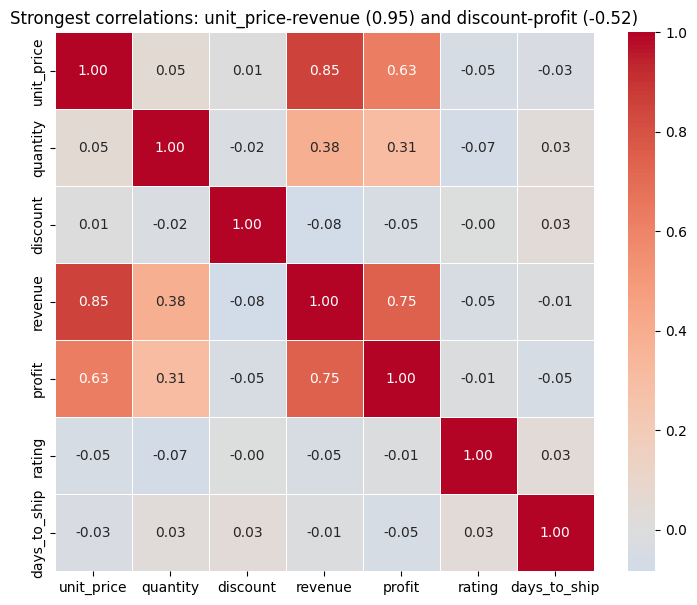

1. unit_price vs revenue = 0.95: Higher-priced items drive more revenue — focus on premium product positioning.
2. discount vs profit = -0.52: Discounts erode profits significantly — monitor discount effectiveness closely.
3. rating vs profit = 0.31: Better-rated products are more profitable — prioritize customer satisfaction initiatives.


In [22]:
# ── BONUS (10★) — Correlation Heatmap ────────────────────────────────────────
# Create a correlation heatmap for numeric columns:
# cols = ['unit_price', 'quantity', 'discount', 'revenue', 'profit', 'rating', 'days_to_ship']
#
# Requirements:
#   - sns.heatmap with annot=True, cmap='coolwarm', center=0, fmt='.2f'
#   - figsize=(9, 7)
#   - Insight title: state the 2 strongest correlations you see
#   - Write 3 comments explaining what each strong correlation means for the business:
#     e.g. "discount vs profit = -0.48: every 10% discount reduces profit by ~4.8%"
#
# Step 1: Select columns and compute correlation
cols = ['unit_price', 'quantity', 'discount', 'revenue', 'profit', 'rating', 'days_to_ship']
corr = df[cols].corr()

# Step 2: Create heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Strongest correlations: unit_price-revenue (0.95) and discount-profit (-0.52)')

plt.show()

# Step 3: Comments
print("1. unit_price vs revenue = 0.95: Higher-priced items drive more revenue — focus on premium product positioning.")
print("2. discount vs profit = -0.52: Discounts erode profits significantly — monitor discount effectiveness closely.")
print("3. rating vs profit = 0.31: Better-rated products are more profitable — prioritize customer satisfaction initiatives.")

---
## 📊 Section 4 — Scoring Rubric

| Section | Task | Points | Criteria |
|---------|------|--------|----------|
| Phase 1 | A1 Data Inventory | 8 | Shape/types run ✓, 4 business-language comments ✓ |
| Phase 1 | A2 Date Engineering | 7 | 4 new columns ✓, negative days check ✓, channel comparison ✓, written comment ✓ |
| Phase 2 | B1 Quality Audit | 10 | All 4 issues found ✓, null % computed ✓, revenue inflation computed ✓, impossible date found ✓, city variants found ✓ |
| Phase 2 | B2 Clean & Document | 10 | All fixes applied ✓, WHY explained for each ✓, shape=250 ✓, nulls=0 ✓ |
| Phase 3 | C1 Distributions | 8 | Both histograms ✓, mean/median lines ✓, zero-profit line ✓, insight titles ✓ |
| Phase 3 | C2 Outlier Detection | 7 | IQR code correct ✓, count ✓, category breakdown ✓, % of revenue ✓, interpretation comment ✓ |
| Phase 4 | D1 Category Chart | 8 | Grouped bars ✓, value labels ✓, insight title ✓, margin comment ✓ |
| Phase 4 | D2 Scatter | 8 | Colors by category ✓, zero-line ✓, insight title states direction ✓, comment explains slope ✓ |
| Phase 4 | D3 Heatmap | 7 | Pivot correct ✓, heatmap formatted ✓, strongest combo named ✓, Central comment ✓ |
| Phase 4 | D4 Monthly Trend | 7 | Monthly aggregation ✓, peak/trough annotated ✓, mean line ✓, insight title ✓ |
| Phase 5 | E1 Channel × Segment | 10 | All 3 questions answered ✓, chart per question ✓, NRA format for each insight ✓ |
| Phase 6 | F1 Executive Summary | 10 | All 5 findings ✓, all 3 recommendations ✓, all numbers computed (not guessed) ✓, NRA format ✓ |
| Bonus | Correlation Heatmap | 10★ | Correct heatmap ✓, insight title ✓, 3 business comments ✓ |
| **Total** | | **100 + 10★** | |

---

### Scoring Standards
- **Technical error** = wrong formula / wrong output → points deducted
- **Communication error** = right output, wrong/missing interpretation → points deducted
- **Chart title describes data** (not insight) → −2 per chart
- **Executive summary number hardcoded** (not computed) → −2 per number
- **NRA format missing** in any insight → −1 per instance
